Para llevar a cabo el fine tuning instalamos las librerías necesarias, con las que tuvimos bastantes problemas. La segunda de ellas, donde cargamos trl, require volver a reiniciar el kernel.

In [ ]:
import accelerate

# Instalar Unsloth y librerías optimizadas para Fine-Tuning rápido en GPU T4
!pip install --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes unsloth_zoo


  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-fd26h2k8/unsloth_e6ceecbec4ae4b1781b1b25a222605e2
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-fd26h2k8/unsloth_e6ceecbec4ae4b1781b1b25a222605e2
  Resolved https://github.com/unslothai/unsloth.git to commit 698ddb34b0d531fb1778abb66862a991e856667b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached trl-0.8.6-py3-none-any.whl.metadata (11 kB)
Using cached trl-0.8.6-py3-none-any.whl (245 kB)
  Attempting uninstall: trl
    Found existing installation: trl 1.10.0
    Uninstalling trl-1.10.0:
      Successfully uninstalled trl-1.10.0


In [ ]:
!pip install --upgrade --no-deps trl

Cargamos las librerías que necesitamos para descargar el modelo original Gemma 3

In [ ]:
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported, standardize_sharegpt
from unsloth.chat_templates import get_chat_template

/usr/local/lib/python3.13/dist-packages/unsloth/__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Descargamos Gemma 3 4b, y configuramos LoRA, para solo entrenar una parte mínima de los parámetros de este modelo.

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096 # Ventana de contexto amplia para la inyección de noticias
dtype = None # Auto-detección (Float16 / Bfloat16)
load_in_4bit = True # Reducción drástica de VRAM

# Cargar Gemma 3 4B optimizado
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# Configurar adapters LoRA para especializar el modelo
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Rango LoRA
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0, # Dropout 0 optimizado por Unsloth
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

==((====))==  Unsloth 2026.8.21: Fast Gemma3 patching. Transformers: 5.15.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Skipping model.vision_tower.encoder.layers.0.self_attn.k_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.0.self_attn.v_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.0.self_attn.q_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.0.self_attn.out_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.0.mlp.fc1: no quant_state found
Skipping model.vision_tower.encoder.layers.0.mlp.fc2: no quant_state found
Skipping model.vision_tower.encoder.layers.1.self_attn.k_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.1.self_attn.v_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.1.self_attn.q_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.1.self_attn.out_proj: no quant_state found
Skipping model.vision_tower.encoder.layers.1.mlp.fc1: no quant_state found
Skipping model.vision_tower.encoder.layers.1.mlp.fc2: no quant_state found
Skipping model.vision_to

Ajustamos el tokenizer.

In [ ]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma", # Aplica el formato oficial de Gemma 3
)

In [ ]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

Pasamos a ejecutar el fine tuning con la función SFTTrainer de la librería trl, utilizando el conjunto de los 18 ejemplos de train. No utilizamos los de test como comprobación para evitar el data leakage, dejándolos para la evaluación del fine tuning mediante Ragas.

In [ ]:
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported, standardize_sharegpt
from unsloth.chat_templates import get_chat_template

# 1. Aplicar la plantilla de Gemma directamente al tokenizer cargado
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma",
)

# 2. Cargar y formatear el dataset a formato chat nativo
dataset = load_dataset("json", data_files="/content/drive/MyDrive/Ollama_app_comentario/train/dataset_market_commentary_train.jsonl", split="train")
dataset = standardize_sharegpt(dataset)

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts }

dataset = dataset.map(formatting_prompts_func, batched = True)

# 3. Solución al conflicto: Asignar el tokenizer al modelo para que Trainer no intente inyectarlo por kwarg
model.config.tokenizer_class = tokenizer.__class__.__name__

# 4. Instanciar SFTTrainer pasando solo argumentos posicionales/básicos
trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 2,
        num_train_epochs = 10,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        output_dir = "outputs",
        save_strategy = "no",
    ),
)

# 5. Iniciar entrenamiento
trainer_stats = trainer.train()

Unsloth: Switching to float32 training since model cannot work with float16
Unsloth: `push_to_hub_token` is not a valid SFTConfig argument for the installed TRL and will be IGNORED. Check the spelling, or your TRL version if this argument used to work.
Unsloth: We found double BOS tokens - we shall remove one automatically.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18 | Num Epochs = 10 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,802,496 of 4,329,881,968 (0.69% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.630740
2,1.632737
3,1.662926
4,1.380969
5,1.268130
6,1.171328
7,1.077766
8,0.977628
9,0.949237
10,0.877376


Ahora tenemos que subir el modelo finetuneado a HF, fijando el nombre del repositorio dentro de nuestra cuenta en Hugging Face.

In [ ]:
from huggingface_hub import login

# Introduce tu token de Hugging Face con permisos de escritura (Write)
login(token="")

In [ ]:
# Reemplaza 'tu-usuario' por tu nombre de usuario en Hugging Face
repo_name = "GuillermoBarrio/gemma3-4b-finetuned-comentarios-lora"

model.push_to_hub(repo_name, tokenizer=tokenizer)
print(f"✅ Adaptadores LoRA subidos a https://huggingface.co/{repo_name}")

Subimos a HF el modelo en formato gguf.

In [ ]:
# Unsloth permite exportar y subir a Hugging Face el GGUF en un solo paso
repo_gguf_name = "GuillermoBarrio/gemma3-4b-finetuned-comentarios-gguf"

model.push_to_hub_gguf(
    repo_gguf_name,
    tokenizer,
    quantization_method="q4_k_m",
    token=""
)
print(f"✅ Modelo GGUF subido a https://huggingface.co/{repo_gguf_name}")

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Converting model to GGUF format...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /tmp/unsloth_gguf_giis7gso/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /tmp/unsloth_gguf_giis7gso.


...

Uploading gemma-3-4b-it.F16-mmproj.gguf...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...a-3-4b-it.F16-mmproj.gguf:   0%|          |  653kB /  851MB            

Uploading config.json...
Uploading Ollama Modelfile...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/GuillermoBarrio/gemma3-4b-finetuned-comentarios-gguf
Unsloth: Cleaning up temporary files...
✅ Modelo GGUF subido a https://huggingface.co/GuillermoBarrio/gemma3-4b-finetuned-comentarios-gguf


Subimos el modelo a nuestro Drive de Google

In [ ]:
# 2. Guardar el archivo GGUF directamente en tu Drive
# (Puedes cambiar 'Mi unidad/Modelos' por la ruta que prefieras)
ruta_drive = "/content/drive/MyDrive/Ollama_app_comentario"

model.save_pretrained_gguf(ruta_drive, tokenizer, quantization_method = "q4_k_m")
print(f"✅ ¡Modelo guardado para siempre en Google Drive!: {ruta_drive}")

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Ollama_app_comentario/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/Ollama_app_comentario.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

model-00002-of-00002.safetensors: downloading bytes:           |  0.00B            



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [04:01<00:00, 120.89s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/Ollama_app_comentario`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/Ollama_app_comentario_gguf/gemma-3-4b-it.F16.gguf', '/content/drive/MyDrive/Ollama_app_comentario_gguf/gemma-3-4b-it.F16-mmproj.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...


Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/drive/MyDrive/Ollama_app_comentario_gguf/gemma-3-4b-it.Q4_K_M.gguf', '/content/drive/MyDrive/Ollama_app_comentario_gguf/gemma-3-4b-it.F16-mmproj.gguf']


Unsloth: example usage for Multimodal LLMs: /root/.unsloth/llama.cpp/llama-mtmd-cli -m /content/drive/MyDrive/Ollama_app_comentario_gguf/gemma-3-4b-it.Q4_K_M.gguf --mmproj /content/drive/MyDrive/Ollama_app_comentario_gguf/gemma-3-4b-it.F16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image
Unsloth: Saved Ollama Modelfile to /content/drive/MyDrive/Ollama_app_comentario_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /content/drive/MyDrive/Ollama_app_comentario_gguf/Modelfile
✅ ¡Modelo guardado para siempre en Google Drive!: /content/drive/MyDrive/Ollama_app_comentario


Finalmente mostramos una gráfica de la evolución de la pérdida (loss) a medida que avanzaba el fine tuning.

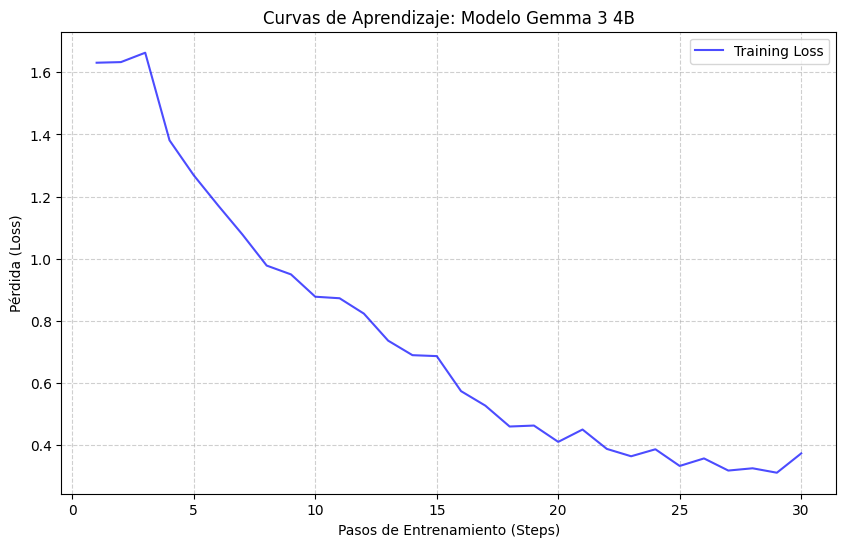

In [ ]:
import matplotlib.pyplot as plt

# Extraer los logs del historial del trainer
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', alpha=0.7)
# if val_loss:
  #  plt.plot(val_steps, val_loss, label='Validation Loss (Test Set)', color='red', marker='o')

plt.title('Curvas de Aprendizaje: Modelo Gemma 3 4B')
plt.xlabel('Pasos de Entrenamiento (Steps)')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()